In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import warnings
warnings.filterwarnings('ignore')

# Carichiamo i dataset
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
gdf = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat.json", on_invalid="ignore")
green = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\park_geojson_lnglat.json", on_invalid="ignore")
fietsen = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\fietsnetten_geojson_lnglat.json")
plans = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Woningbouwplannen_geojson_lnglat.json", on_invalid="ignore")

# Cerchiamo il Jordaan nei buurten
jordaan_buurt = buurten[buurten['Buurt'].str.contains('Jordaan', case=False, na=False)]
print(f"Quartieri trovati con 'Jordaan': {len(jordaan_buurt)}")
print(jordaan_buurt[['Buurt', 'Stadsdeel']].to_string())

Quartieri trovati con 'Jordaan': 0
Empty DataFrame
Columns: [Buurt, Stadsdeel]
Index: []


In [2]:
# Vediamo tutti i quartieri di West e Centrum
print(buurten[buurten['Stadsdeel'] == 'West']['Buurt'].sort_values().to_string())

131                   Balboaplein e.o.
110    Bedrijvencentrum Westerkwartier
104          Bedrijventerrein Landlust
138                 Bellamybuurt-Noord
139                  Bellamybuurt-Zuid
144                        Borgerbuurt
102                           Bosleeuw
119                      Buyskade e.o.
133                 Columbusplein e.o.
84                        Contactbuurt
148                   Cremerbuurt-Oost
146                   Cremerbuurt-West
140                Da Costabuurt-Noord
145                 Da Costabuurt-Zuid
137                 De Wester Quartier
117               De Wittenbuurt-Noord
118                De Wittenbuurt-Zuid
106              Erasmusparkbuurt-Oost
109              Erasmusparkbuurt-West
115              Fannius Scholtenbuurt
134         Filips van Almondekwartier
120        Frederik Hendrikbuurt-Noord
122     Frederik Hendrikbuurt-Zuidoost
121     Frederik Hendrikbuurt-Zuidwest
111                        GWL-terrein
129                     G

In [3]:
print(buurten[buurten['Stadsdeel'] == 'Centrum']['Buurt'].sort_values().to_string())

60       Alexanderplein e.o.
48           Amstelveldbuurt
8       Anjeliersbuurt-Noord
10       Anjeliersbuurt-Zuid
33           BG-terrein e.o.
27            Begijnhofbuurt
12          Bloemgrachtbuurt
31           Burgwallen-Oost
65          Czaar Peterbuurt
55              Den Texbuurt
7              Driehoekbuurt
15         Elandsgrachtbuurt
19        Felix Meritisbuurt
56       Frederikspleinbuurt
44            Geelvinckbuurt
13       Groenmarktkadebuurt
5       Haarlemmerbuurt-Oost
4       Haarlemmerbuurt-West
22                 Hemelrijk
66                 Het Funen
67                  Kadijken
28            Kalverdriehoek
62                Kattenburg
68              Kazernebuurt
29               Kop Zeedijk
17          Langestraat e.o.
35                   Lastage
50     Leidsebuurt-Noordoost
49     Leidsebuurt-Noordwest
54      Leidsebuurt-Zuidoost
53      Leidsebuurt-Zuidwest
20        Leidsegracht-Noord
43         Leidsegracht-Zuid
18          Leliegracht e.o.
61      Marine

In [4]:
jordaan_nomi = [
    'Anjeliersbuurt-Noord', 'Anjeliersbuurt-Zuid',
    'Bloemgrachtbuurt', 'Driehoekbuurt',
    'Elandsgrachtbuurt', 'Marnixbuurt-Noord',
    'Marnixbuurt-Midden', 'Marnixbuurt-Zuid',
    'Passeerdersgrachtbuurt'
]

jordaan = buurten[buurten['Buurt'].isin(jordaan_nomi)]
print(f"Sotto-quartieri del Jordaan trovati: {len(jordaan)}")
print(jordaan['Buurt'].to_string())

Sotto-quartieri del Jordaan trovati: 9
6          Marnixbuurt-Noord
7              Driehoekbuurt
8       Anjeliersbuurt-Noord
10       Anjeliersbuurt-Zuid
11        Marnixbuurt-Midden
12          Bloemgrachtbuurt
14          Marnixbuurt-Zuid
15         Elandsgrachtbuurt
16    Passeerdersgrachtbuurt


In [5]:
# Uniamo i sotto-quartieri in un unico poligono
jordaan_union = jordaan.dissolve()

# Portiamo tutto nello stesso CRS
gdf_proj = gdf.to_crs(jordaan.crs)

# Selezioniamo gli edifici dentro il Jordaan
edifici_jordaan = gpd.sjoin(gdf_proj, jordaan[['Buurt', 'geometry']], 
                             how='inner', predicate='within')

# Puliamo gli anni non validi
edifici_jordaan = edifici_jordaan[edifici_jordaan['Bouwjaar'] > 1500]

print(f"Edifici nel Jordaan: {len(edifici_jordaan)}")
print(f"Anno più antico: {edifici_jordaan['Bouwjaar'].min()}")
print(f"Anno più recente: {edifici_jordaan['Bouwjaar'].max()}")
print(f"Anno mediano: {edifici_jordaan['Bouwjaar'].median():.0f}")

Edifici nel Jordaan: 2749
Anno più antico: 1612
Anno più recente: 2023
Anno mediano: 1901


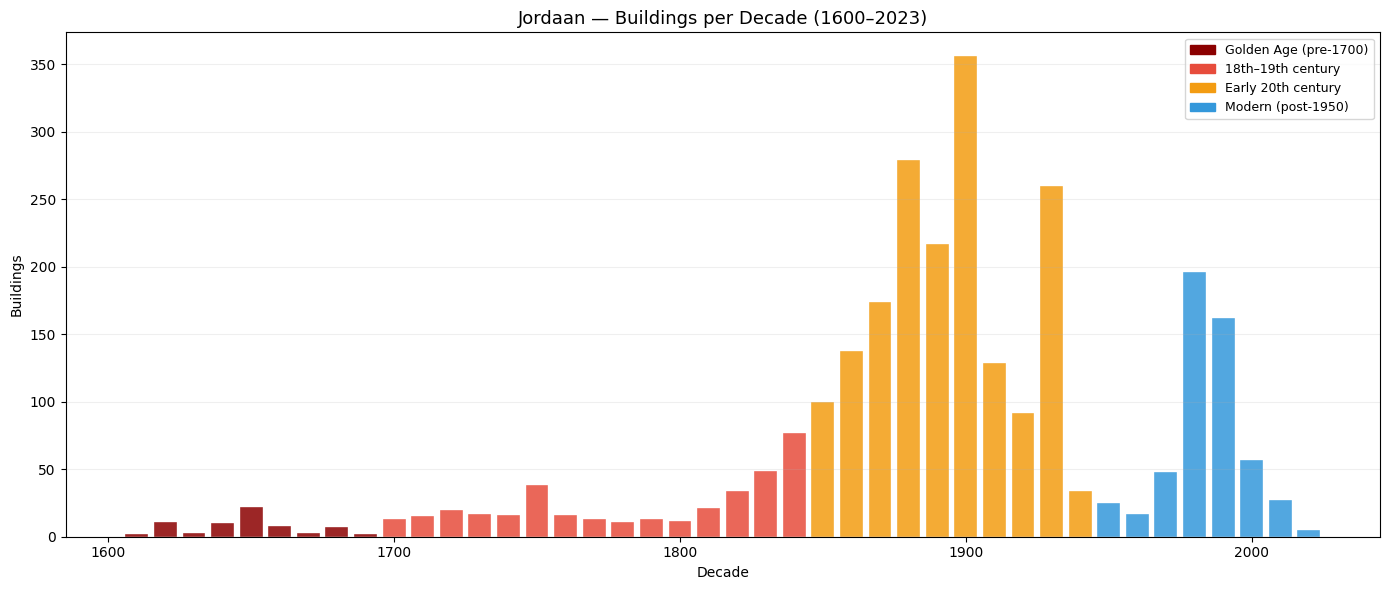

In [6]:
# Distribuzione per decennio
edifici_jordaan['Decennio'] = (edifici_jordaan['Bouwjaar'] // 10) * 10
per_decennio = edifici_jordaan.groupby('Decennio').size().reset_index()
per_decennio.columns = ['Decennio', 'Edifici']

fig, ax = plt.subplots(figsize=(14, 6))

# Coloriamo per epoca
colori = ['#8B0000' if d < 1700 else '#e74c3c' if d < 1850 else 
          '#f39c12' if d < 1950 else '#3498db' 
          for d in per_decennio['Decennio']]

ax.bar(per_decennio['Decennio'], per_decennio['Edifici'],
       width=8, color=colori, alpha=0.85, edgecolor='white', linewidth=0.3)

ax.set_title('Jordaan — Buildings per Decade (1600–2023)', fontsize=13)
ax.set_xlabel('Decade')
ax.set_ylabel('Buildings')
ax.grid(True, alpha=0.2, axis='y')

# Legenda manuale
from matplotlib.patches import Patch
legenda = [
    Patch(color='#8B0000', label='Golden Age (pre-1700)'),
    Patch(color='#e74c3c', label='18th–19th century'),
    Patch(color='#f39c12', label='Early 20th century'),
    Patch(color='#3498db', label='Modern (post-1950)')
]
ax.legend(handles=legenda, fontsize=9)

plt.tight_layout()
plt.savefig('jordaan_decades.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Centroide del Jordaan per centrare la mappa
centro = jordaan_union.geometry.centroid.iloc[0]

m = folium.Map(location=[centro.y, centro.x], 
               zoom_start=15,
               tiles='CartoDB positron')

# --- LAYER 1: Confini sotto-quartieri ---
confini_layer = folium.FeatureGroup(name='Jordaan Neighbourhoods', show=True)
folium.GeoJson(
    jordaan.__geo_interface__,
    style_function=lambda x: {
        'fillColor': 'transparent',
        'color': '#333333',
        'weight': 2,
        'fillOpacity': 0
    },
    tooltip=folium.GeoJsonTooltip(fields=['Buurt'], aliases=['Quartiere:'])
).add_to(confini_layer)
confini_layer.add_to(m)

# --- LAYER 2: Edifici colorati per anno ---
edifici_layer = folium.FeatureGroup(name='Buildings by Age', show=True)

for _, row in edifici_jordaan.iterrows():
    anno = row['Bouwjaar']
    if anno < 1700:
        colore = '#8B0000'
    elif anno < 1850:
        colore = '#e74c3c'
    elif anno < 1950:
        colore = '#f39c12'
    else:
        colore = '#3498db'
    
    folium.GeoJson(
        row['geometry'].__geo_interface__,
        style_function=lambda x, c=colore: {
            'fillColor': c,
            'color': c,
            'weight': 0.3,
            'fillOpacity': 0.7
        },
        tooltip=f"Anno: {int(anno)}"
    ).add_to(edifici_layer)

edifici_layer.add_to(m)

# --- LAYER 3: Verde ---
green_proj = green.to_crs(jordaan.crs)
green_jordaan = gpd.sjoin(green_proj, jordaan[['geometry']], 
                           how='inner', predicate='intersects')

verde_layer = folium.FeatureGroup(name='Green Areas', show=True)
folium.GeoJson(
    green_jordaan.__geo_interface__,
    style_function=lambda x: {
        'fillColor': '#2ecc71',
        'color': '#27ae60',
        'weight': 1,
        'fillOpacity': 0.6
    },
    tooltip=folium.GeoJsonTooltip(fields=['Naam'], aliases=['Park:'])
).add_to(verde_layer)
verde_layer.add_to(m)

# --- LAYER 4: Piste ciclabili ---
fietsen_proj = fietsen.to_crs(jordaan.crs)
fietsen_jordaan = gpd.sjoin(fietsen_proj, jordaan[['geometry']], 
                             how='inner', predicate='intersects')

fietsen_layer = folium.FeatureGroup(name='Cycling Network', show=False)
folium.GeoJson(
    fietsen_jordaan.__geo_interface__,
    style_function=lambda x: {
        'color': '#e74c3c',
        'weight': 2,
        'opacity': 0.7
    }
).add_to(fietsen_layer)
fietsen_layer.add_to(m)

# Controllo layer
folium.LayerControl(collapsed=False).add_to(m)

m.save('jordaan_dashboard.html')
print("Mappa Jordaan salvata!")

Mappa Jordaan salvata!


In [9]:
report = """# Jordaan Urban Analysis Report

## Overview
The Jordaan is one of Amsterdam's most iconic neighbourhoods, 
located in the western part of the historic centre (Stadsdeel Centrum). 
Originally built as a working-class district in the early 17th century, 
it has undergone significant transformation over four centuries.

## Key Statistics
- **Total buildings analysed:** 2,749
- **Oldest building:** 1612
- **Most recent:** 2023  
- **Median construction year:** 1901
- **Sub-neighbourhoods:** 9

## Historical Phases

### Golden Age (1600–1700)
The Jordaan was founded around 1612 as a working-class district 
outside the main canal ring. Construction was modest — small 
houses for labourers, craftsmen, and immigrants. Few of these 
original structures survive intact today.

### Stagnation (1700–1850)
Following the decline of the VOC and Amsterdam's economic contraction, 
the Jordaan saw minimal new construction for over 150 years. 
The neighbourhood became increasingly overcrowded and deteriorated.

### Industrial Expansion (1850–1950)
The most intensive construction period. The decade 1900–1910 
alone produced over 350 new buildings — the dense brick housing 
that defines the neighbourhood's visual character today.
The Jordaan reached its maximum population density in this period.

### Post-war Decline (1950–1980)
Construction dropped sharply. The Jordaan was considered a 
degraded, undesirable neighbourhood. Many residents moved 
to new peripheral districts.

### Gentrification (1980–present)
A dramatic reversal. Artists and young professionals rediscovered 
the Jordaan in the 1980s, attracted by low rents and historic character. 
Today it is among Amsterdam's most expensive neighbourhoods.
The data shows a clear construction revival from the 1990s onward — 
renovation, infill, and new development within the existing urban fabric.

## Urban Character
- **Cycling:** Formal cycling infrastructure follows perimeter streets. 
  Internal circulation relies on low-traffic streets shared with cyclists — 
  a typical Dutch approach where design replaces signage.
- **Green space:** Limited within the dense urban fabric. 
  The neighbourhood relies on canal-side public space rather than parks.

## Conclusion
The Jordaan is a case study in urban resilience. 
What appears as a coherent historic district is in reality 
a layered accumulation of four distinct construction phases, 
each reflecting the economic and social conditions of its time.
The data makes the invisible visible.

---
*Analysis based on Amsterdam Open Data — Bouwjaar Pand dataset*  
*Tools: Python · GeoPandas · Folium · Matplotlib*
"""

# Salviamo il report
with open('jordaan_report.md', 'w', encoding='utf-8') as f:
    f.write(report)

print("Report salvato!")
print(report)

Report salvato!
# Jordaan Urban Analysis Report

## Overview
The Jordaan is one of Amsterdam's most iconic neighbourhoods, 
located in the western part of the historic centre (Stadsdeel Centrum). 
Originally built as a working-class district in the early 17th century, 
it has undergone significant transformation over four centuries.

## Key Statistics
- **Total buildings analysed:** 2,749
- **Oldest building:** 1612
- **Most recent:** 2023  
- **Median construction year:** 1901
- **Sub-neighbourhoods:** 9

## Historical Phases

### Golden Age (1600–1700)
The Jordaan was founded around 1612 as a working-class district 
outside the main canal ring. Construction was modest — small 
houses for labourers, craftsmen, and immigrants. Few of these 
original structures survive intact today.

### Stagnation (1700–1850)
Following the decline of the VOC and Amsterdam's economic contraction, 
the Jordaan saw minimal new construction for over 150 years. 
The neighbourhood became increasingly overcro